**The implementation includes three required parts:**

1. Blockchain consensus simulation
2. ML-based malicious node detection
3. Comparative result extraction for manuscript

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import all required libraries and create the directory structure for storing simulation outputs, result tables, and manuscript figures.
import os
import random
import hashlib
import time
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Research Projects/Blockchain"
RESULT_DIR = f"{BASE_DIR}/results"
GRAPH_DIR = f"{RESULT_DIR}/graphs"

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)

In [ ]:
#Cell 2: Utility functions
# Define helper functions for cryptographic hashing, decentralization metrics (Gini coefficient and validator concentration),
#and configurable network delay simulation.
def sha256(data):
    return hashlib.sha256(str(data).encode()).hexdigest()

def gini_coefficient(values):
    values = np.array(values, dtype=float)
    if np.amin(values) < 0:
        values -= np.amin(values)
    values += 1e-9
    values = np.sort(values)
    n = len(values)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * values)) / (n * np.sum(values))

def validator_concentration(values, top_ratio=0.1):
    values = np.array(values, dtype=float)
    values = np.sort(values)[::-1]
    k = max(1, int(len(values) * top_ratio))
    return np.sum(values[:k]) / (np.sum(values) + 1e-9)

def random_delay(base=0.05, jitter=0.15):
    return max(0.001, np.random.normal(base, jitter))

In [ ]:
#Cell 3: Transaction, block, node, and ledger classes
# Create the core blockchain data structures representing transactions, blocks, and network nodes along with their operational and behavioral attributes.

@dataclass
class Transaction:
    tx_id: str
    sender: int
    receiver: int
    amount: float
    timestamp: float

@dataclass
class Block:
    block_id: str
    proposer_id: int
    previous_hash: str
    transactions: list
    timestamp: float
    consensus: str
    nonce: int = 0
    block_hash: str = ""

    def compute_hash(self):
        block_content = (
            str(self.block_id) +
            str(self.proposer_id) +
            str(self.previous_hash) +
            str([tx.tx_id for tx in self.transactions]) +
            str(self.timestamp) +
            str(self.nonce)
        )
        return sha256(block_content)

@dataclass
class Node:
    node_id: int
    is_malicious: bool = False
    hash_power: float = 1.0
    stake: float = 1.0
    authority: bool = False
    delegate_votes: float = 0.0
    ledger: list = field(default_factory=list)

    block_proposal_count: int = 0
    invalid_block_count: int = 0
    fork_contribution_count: int = 0
    validation_failure_count: int = 0
    missed_validation_count: int = 0
    censorship_count: int = 0
    peer_disconnect_count: int = 0
    total_delay: float = 0.0
    message_count: int = 0
    stake_change_rate: float = 0.0

    def avg_delay(self):
        return self.total_delay / max(1, self.message_count)

    def reset_round_metrics(self):
        self.total_delay = 0
        self.message_count = 0

In [ ]:
#Cell 4: Blockchain simulator
# Implement the complete blockchain simulation engine including transaction processing,
#consensus execution, attack modeling, block validation, metric collection, and node behavior logging.

class BlockchainSimulator:
    def __init__(
        self,
        consensus="PoW",
        num_nodes=50,
        num_transactions=1000,
        malicious_ratio=0.1,
        attack_type="None",
        rounds=30
    ):
        self.consensus = consensus
        self.num_nodes = num_nodes
        self.num_transactions = num_transactions
        self.malicious_ratio = malicious_ratio
        self.attack_type = attack_type
        self.rounds = rounds

        self.nodes = []
        self.pending_transactions = []
        self.chain = []
        self.metrics = []

        self.bandwidth_usage = 0
        self.cpu_cost = 0
        self.energy_cost = 0
        self.fork_count = 0
        self.failed_finalizations = 0
        self.attack_success_count = 0
        self.confirmation_latencies = []

        self.init_nodes()
        self.create_genesis_block()

    def init_nodes(self):
        malicious_count = int(self.num_nodes * self.malicious_ratio)
        malicious_ids = set(random.sample(range(self.num_nodes), malicious_count))

        for i in range(self.num_nodes):
            node = Node(
                node_id=i,
                is_malicious=i in malicious_ids,
                hash_power=np.random.exponential(1.0),
                stake=np.random.exponential(100.0),
                authority=False,
                delegate_votes=0
            )
            self.nodes.append(node)

        if self.consensus == "PoA":
            authority_count = max(3, int(self.num_nodes * 0.15))
            authority_ids = random.sample(range(self.num_nodes), authority_count)
            for i in authority_ids:
                self.nodes[i].authority = True

        if self.consensus == "DPoS":
            for node in self.nodes:
                node.delegate_votes = np.random.exponential(50.0)

    def create_genesis_block(self):
        genesis = Block(
            block_id="genesis",
            proposer_id=-1,
            previous_hash="0",
            transactions=[],
            timestamp=time.time(),
            consensus=self.consensus
        )
        genesis.block_hash = genesis.compute_hash()
        self.chain.append(genesis)

    def generate_transactions(self):
        tx_per_round = max(1, self.num_transactions // self.rounds)
        transactions = []

        for _ in range(tx_per_round):
            sender = random.randint(0, self.num_nodes - 1)
            receiver = random.randint(0, self.num_nodes - 1)
            amount = round(random.uniform(1, 100), 2)
            tx = Transaction(
                tx_id=sha256(f"{sender}-{receiver}-{amount}-{time.time()}-{random.random()}"),
                sender=sender,
                receiver=receiver,
                amount=amount,
                timestamp=time.time()
            )
            transactions.append(tx)

        self.pending_transactions.extend(transactions)
        return transactions

    def select_proposer(self):
        if self.consensus == "PoW":
            powers = np.array([n.hash_power for n in self.nodes])
            probs = powers / powers.sum()
            return np.random.choice(self.nodes, p=probs)

        elif self.consensus == "PoS":
            stakes = np.array([n.stake for n in self.nodes])
            probs = stakes / stakes.sum()
            return np.random.choice(self.nodes, p=probs)

        elif self.consensus == "DPoS":
            delegates = sorted(self.nodes, key=lambda n: n.delegate_votes, reverse=True)
            top_delegates = delegates[:max(3, int(self.num_nodes * 0.1))]
            return random.choice(top_delegates)

        elif self.consensus == "PBFT":
            return random.choice(self.nodes)

        elif self.consensus == "PoA":
            authorities = [n for n in self.nodes if n.authority]
            return random.choice(authorities)

        elif self.consensus == "PoH":
            return self.nodes[len(self.chain) % self.num_nodes]

        else:
            return random.choice(self.nodes)

    def simulate_network_delay(self):
        delays = []
        for node in self.nodes:
            delay = random_delay()
            if node.is_malicious:
                delay *= random.uniform(1.5, 4.0)
            node.total_delay += delay
            node.message_count += 1
            delays.append(delay)

        avg_delay = np.mean(delays)
        self.bandwidth_usage += self.num_nodes * 0.5
        return avg_delay

    def apply_attack(self, proposer):
        success = False

        if self.attack_type == "None":
            return False

        malicious_nodes = [n for n in self.nodes if n.is_malicious]
        malicious_fraction = len(malicious_nodes) / self.num_nodes

        if self.attack_type == "Sybil":
            if malicious_fraction >= 0.25 and proposer.is_malicious:
                success = np.random.rand() < 0.35

        elif self.attack_type == "Collusion":
            if malicious_fraction >= 0.30:
                success = np.random.rand() < 0.45

        elif self.attack_type == "NetworkPartition":
            if malicious_fraction >= 0.20:
                success = np.random.rand() < 0.30
                if success:
                    self.fork_count += 1

        elif self.attack_type == "SelfishMining":
            if self.consensus == "PoW" and proposer.is_malicious:
                success = np.random.rand() < 0.40
                if success:
                    self.fork_count += 1

        elif self.attack_type == "Censorship":
            if proposer.is_malicious:
                success = np.random.rand() < 0.50
                proposer.censorship_count += 1

        if success:
            self.attack_success_count += 1
            proposer.invalid_block_count += 1

        return success

    def validate_block(self, proposer):
        malicious_nodes = [n for n in self.nodes if n.is_malicious]
        malicious_fraction = len(malicious_nodes) / self.num_nodes

        if self.consensus == "PBFT":
            fault_threshold = 1 / 3
            message_complexity = self.num_nodes ** 2
            self.bandwidth_usage += message_complexity * 0.01

            if malicious_fraction >= fault_threshold:
                self.failed_finalizations += 1
                return False

        if proposer.is_malicious:
            failure_prob = 0.25
            if np.random.rand() < failure_prob:
                proposer.validation_failure_count += 1
                return False

        return True

    def consensus_costs(self):
        if self.consensus == "PoW":
            self.cpu_cost += self.num_nodes * random.uniform(5, 10)
            self.energy_cost += self.num_nodes * random.uniform(8, 15)
            latency_factor = random.uniform(2.5, 5.0)

        elif self.consensus == "PoS":
            self.cpu_cost += self.num_nodes * random.uniform(1, 2)
            self.energy_cost += self.num_nodes * random.uniform(0.5, 1.5)
            latency_factor = random.uniform(1.0, 2.0)

        elif self.consensus == "DPoS":
            self.cpu_cost += self.num_nodes * random.uniform(0.8, 1.5)
            self.energy_cost += self.num_nodes * random.uniform(0.4, 1.0)
            latency_factor = random.uniform(0.8, 1.6)

        elif self.consensus == "PBFT":
            self.cpu_cost += self.num_nodes * random.uniform(2, 4)
            self.energy_cost += self.num_nodes * random.uniform(1, 2)
            latency_factor = random.uniform(2.0, 4.5)

        elif self.consensus == "PoA":
            self.cpu_cost += self.num_nodes * random.uniform(0.5, 1.0)
            self.energy_cost += self.num_nodes * random.uniform(0.2, 0.8)
            latency_factor = random.uniform(0.5, 1.2)

        elif self.consensus == "PoH":
            self.cpu_cost += self.num_nodes * random.uniform(1, 2)
            self.energy_cost += self.num_nodes * random.uniform(0.8, 1.5)
            latency_factor = random.uniform(0.6, 1.4)

        else:
            latency_factor = 1.0

        return latency_factor

    def run(self):
        start_time = time.time()
        total_finalized_tx = 0

        for r in range(self.rounds):
            new_txs = self.generate_transactions()
            proposer = self.select_proposer()
            proposer.block_proposal_count += 1

            avg_delay = self.simulate_network_delay()
            latency_factor = self.consensus_costs()
            attack_success = self.apply_attack(proposer)

            block_size = min(len(self.pending_transactions), random.randint(20, 100))
            block_txs = self.pending_transactions[:block_size]

            valid = self.validate_block(proposer)

            if valid and not attack_success:
                prev_hash = self.chain[-1].block_hash
                block = Block(
                    block_id=f"{self.consensus}_{r}_{time.time()}",
                    proposer_id=proposer.node_id,
                    previous_hash=prev_hash,
                    transactions=block_txs,
                    timestamp=time.time(),
                    consensus=self.consensus
                )

                if self.consensus == "PoW":
                    block.nonce = random.randint(1000, 999999)

                if self.consensus == "PoH":
                    block.timestamp = r

                block.block_hash = block.compute_hash()
                self.chain.append(block)

                proposer.ledger.append(block)
                self.pending_transactions = self.pending_transactions[block_size:]

                total_finalized_tx += len(block_txs)

                confirmation_latency = avg_delay * latency_factor
                self.confirmation_latencies.append(confirmation_latency)

                if self.consensus == "PoW":
                    if np.random.rand() < 0.08:
                        self.fork_count += 1
                        proposer.fork_contribution_count += 1

                if self.consensus == "PoS":
                    proposer.stake += random.uniform(0.1, 2.0)
                    proposer.stake_change_rate += random.uniform(0.01, 0.05)

            else:
                self.failed_finalizations += 1

        elapsed = max(1e-6, time.time() - start_time)
        avg_latency = np.mean(self.confirmation_latencies) if self.confirmation_latencies else 0
        throughput = total_finalized_tx / max(1e-6, np.sum(self.confirmation_latencies) + 1)

        values = self.get_distribution_values()
        gini = gini_coefficient(values)
        concentration = validator_concentration(values)

        attack_rate = self.attack_success_count / max(1, self.rounds)
        fork_rate = self.fork_count / max(1, len(self.chain))
        storage_growth = len(self.chain) * 1.2

        result = {
            "consensus": self.consensus,
            "num_nodes": self.num_nodes,
            "num_transactions": self.num_transactions,
            "malicious_ratio": self.malicious_ratio,
            "attack_type": self.attack_type,
            "throughput_tps": throughput,
            "confirmation_latency": avg_latency,
            "fork_rate": fork_rate,
            "cpu_cost": self.cpu_cost,
            "energy_cost": self.energy_cost,
            "bandwidth_usage": self.bandwidth_usage,
            "storage_growth": storage_growth,
            "attack_success_rate": attack_rate,
            "failed_finalization_rate": self.failed_finalizations / max(1, self.rounds),
            "gini_coefficient": gini,
            "validator_concentration": concentration,
            "chain_length": len(self.chain)
        }

        return result

    def get_distribution_values(self):
        if self.consensus == "PoW":
            return [n.hash_power for n in self.nodes]
        elif self.consensus == "PoS":
            return [n.stake for n in self.nodes]
        elif self.consensus == "DPoS":
            return [n.delegate_votes for n in self.nodes]
        elif self.consensus == "PoA":
            return [1 if n.authority else 0 for n in self.nodes]
        else:
            return [1 for _ in self.nodes]

    def extract_node_features(self):
        rows = []

        for n in self.nodes:
            row = {
                "consensus": self.consensus,
                "attack_type": self.attack_type,
                "node_id": n.node_id,
                "block_proposal_count": n.block_proposal_count,
                "invalid_block_count": n.invalid_block_count,
                "average_message_delay": n.avg_delay(),
                "fork_contribution_count": n.fork_contribution_count,
                "validation_failure_count": n.validation_failure_count,
                "missed_validation_count": n.missed_validation_count,
                "censorship_count": n.censorship_count,
                "peer_disconnect_count": n.peer_disconnect_count,
                "stake_change_rate": n.stake_change_rate,
                "hash_power": n.hash_power,
                "stake": n.stake,
                "delegate_votes": n.delegate_votes,
                "is_authority": int(n.authority),
                "label": int(n.is_malicious)
            }
            rows.append(row)

        return pd.DataFrame(rows)

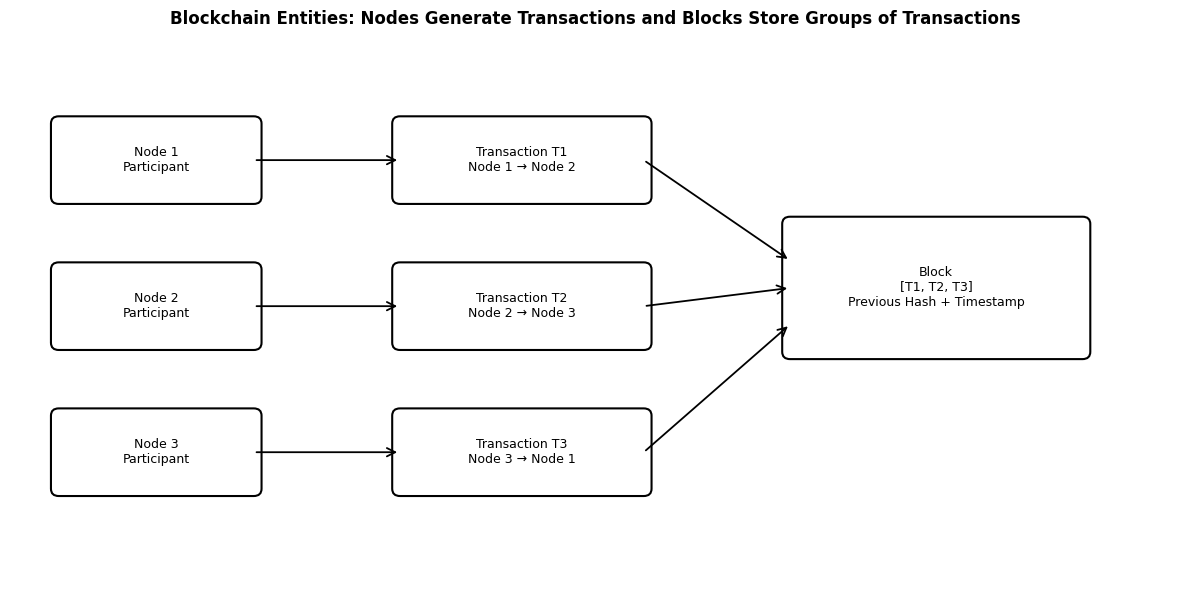

In [ ]:
# CELL 4A: Visualization of blockchain entities, network structure, consensus workflow, and simulation architecture

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

os.makedirs(f"{GRAPH_DIR}/architecture", exist_ok=True)

def draw_box(ax, x, y, text, width=2.7, height=0.7):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.08",
        linewidth=1.5,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=9
    )

def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.3,
        color="black"
    )
    ax.add_patch(arrow)

# ---------------------------------------------------------
# Figure 1: Nodes, transactions, and blocks
# ---------------------------------------------------------

def visualize_transactions_blocks_nodes():
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 6)
    ax.axis("off")

    draw_box(ax, 0.5, 4.2, "Node 1\nParticipant", 2, 0.8)
    draw_box(ax, 0.5, 2.6, "Node 2\nParticipant", 2, 0.8)
    draw_box(ax, 0.5, 1.0, "Node 3\nParticipant", 2, 0.8)

    draw_box(ax, 4.0, 4.2, "Transaction T1\nNode 1 → Node 2", 2.5, 0.8)
    draw_box(ax, 4.0, 2.6, "Transaction T2\nNode 2 → Node 3", 2.5, 0.8)
    draw_box(ax, 4.0, 1.0, "Transaction T3\nNode 3 → Node 1", 2.5, 0.8)

    draw_box(ax, 8.0, 2.5, "Block\n[T1, T2, T3]\nPrevious Hash + Timestamp", 3, 1.4)

    draw_arrow(ax, (2.5, 4.6), (4.0, 4.6))
    draw_arrow(ax, (2.5, 3.0), (4.0, 3.0))
    draw_arrow(ax, (2.5, 1.4), (4.0, 1.4))

    draw_arrow(ax, (6.5, 4.6), (8.0, 3.5))
    draw_arrow(ax, (6.5, 3.0), (8.0, 3.2))
    draw_arrow(ax, (6.5, 1.4), (8.0, 2.8))

    ax.set_title(
        "Blockchain Entities: Nodes Generate Transactions and Blocks Store Groups of Transactions",
        fontsize=12,
        fontweight="bold"
    )

    path = f"{GRAPH_DIR}/architecture/entities_transactions_blocks_nodes.png"
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()

visualize_transactions_blocks_nodes()

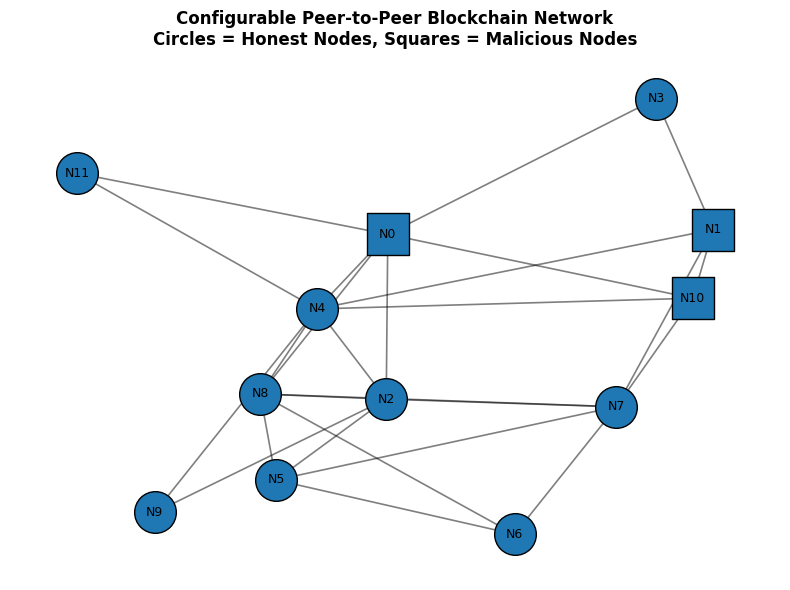

In [ ]:
# CELL 4B: Visualization of configurable blockchain peer-to-peer network

def visualize_p2p_network(num_nodes=12, malicious_ratio=0.25):
    G = nx.erdos_renyi_graph(num_nodes, 0.35, seed=SEED)

    malicious_count = int(num_nodes * malicious_ratio)
    malicious_nodes = set(random.sample(list(G.nodes()), malicious_count))

    pos = nx.spring_layout(G, seed=SEED)

    honest_nodes = [n for n in G.nodes() if n not in malicious_nodes]
    bad_nodes = [n for n in G.nodes() if n in malicious_nodes]

    plt.figure(figsize=(8, 6))

    nx.draw_networkx_edges(G, pos, alpha=0.5, width=1.2)
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=honest_nodes,
        node_size=900,
        edgecolors="black"
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=bad_nodes,
        node_size=900,
        edgecolors="black",
        node_shape="s"
    )
    nx.draw_networkx_labels(G, pos, labels={n: f"N{n}" for n in G.nodes()}, font_size=9)

    plt.title(
        "Configurable Peer-to-Peer Blockchain Network\nCircles = Honest Nodes, Squares = Malicious Nodes",
        fontsize=12,
        fontweight="bold"
    )
    plt.axis("off")

    path = f"{GRAPH_DIR}/architecture/configurable_p2p_network.png"
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()

visualize_p2p_network()

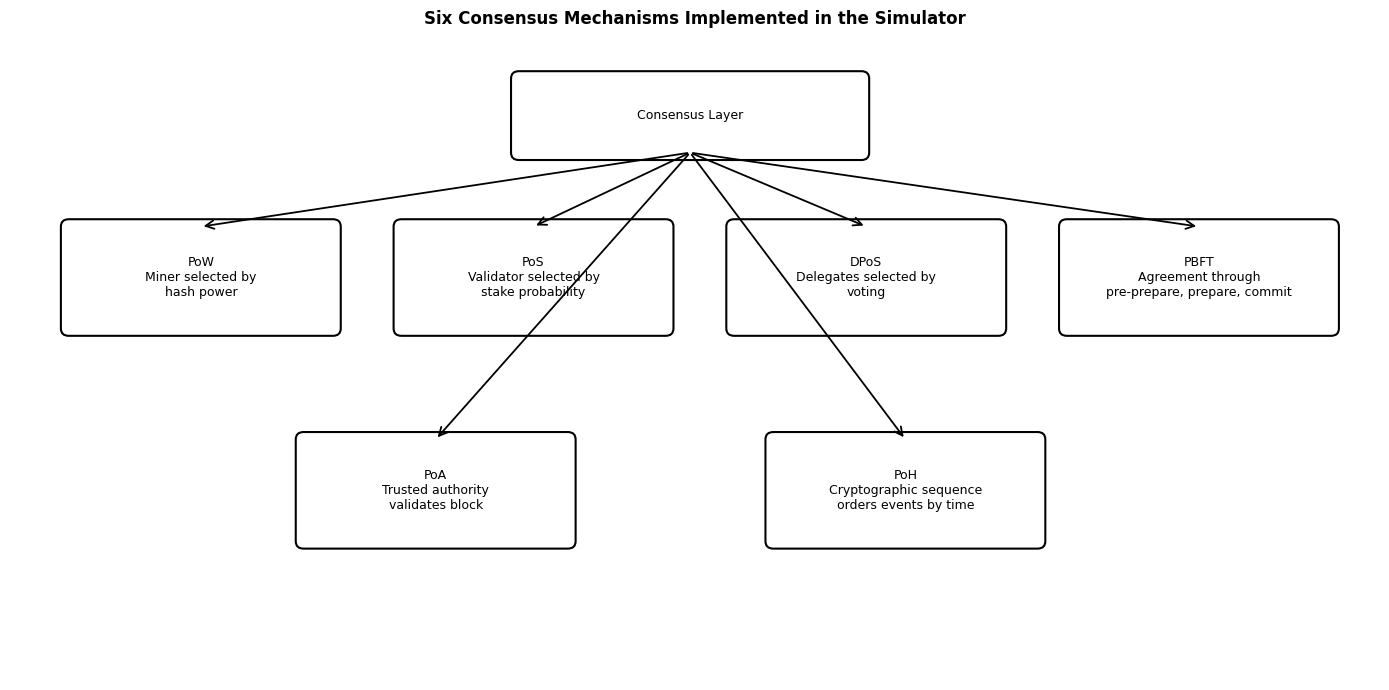

In [ ]:
# CELL 4C: Visualization of six consensus mechanisms

def visualize_consensus_mechanisms():
    mechanisms = {
        "PoW": "Miner selected by\nhash power",
        "PoS": "Validator selected by\nstake probability",
        "DPoS": "Delegates selected by\nvoting",
        "PBFT": "Agreement through\npre-prepare, prepare, commit",
        "PoA": "Trusted authority\nvalidates block",
        "PoH": "Cryptographic sequence\norders events by time"
    }

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 7)
    ax.axis("off")

    draw_box(ax, 5.2, 5.7, "Consensus Layer", 3.5, 0.8)

    positions = [
        (0.6, 3.8),
        (4.0, 3.8),
        (7.4, 3.8),
        (10.8, 3.8),
        (3.0, 1.5),
        (7.8, 1.5)
    ]

    for (name, desc), (x, y) in zip(mechanisms.items(), positions):
        draw_box(ax, x, y, f"{name}\n{desc}", 2.7, 1.1)
        draw_arrow(ax, (6.95, 5.7), (x + 1.35, y + 1.1))

    ax.set_title(
        "Six Consensus Mechanisms Implemented in the Simulator",
        fontsize=12,
        fontweight="bold"
    )

    path = f"{GRAPH_DIR}/architecture/six_consensus_mechanisms.png"
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()

visualize_consensus_mechanisms()

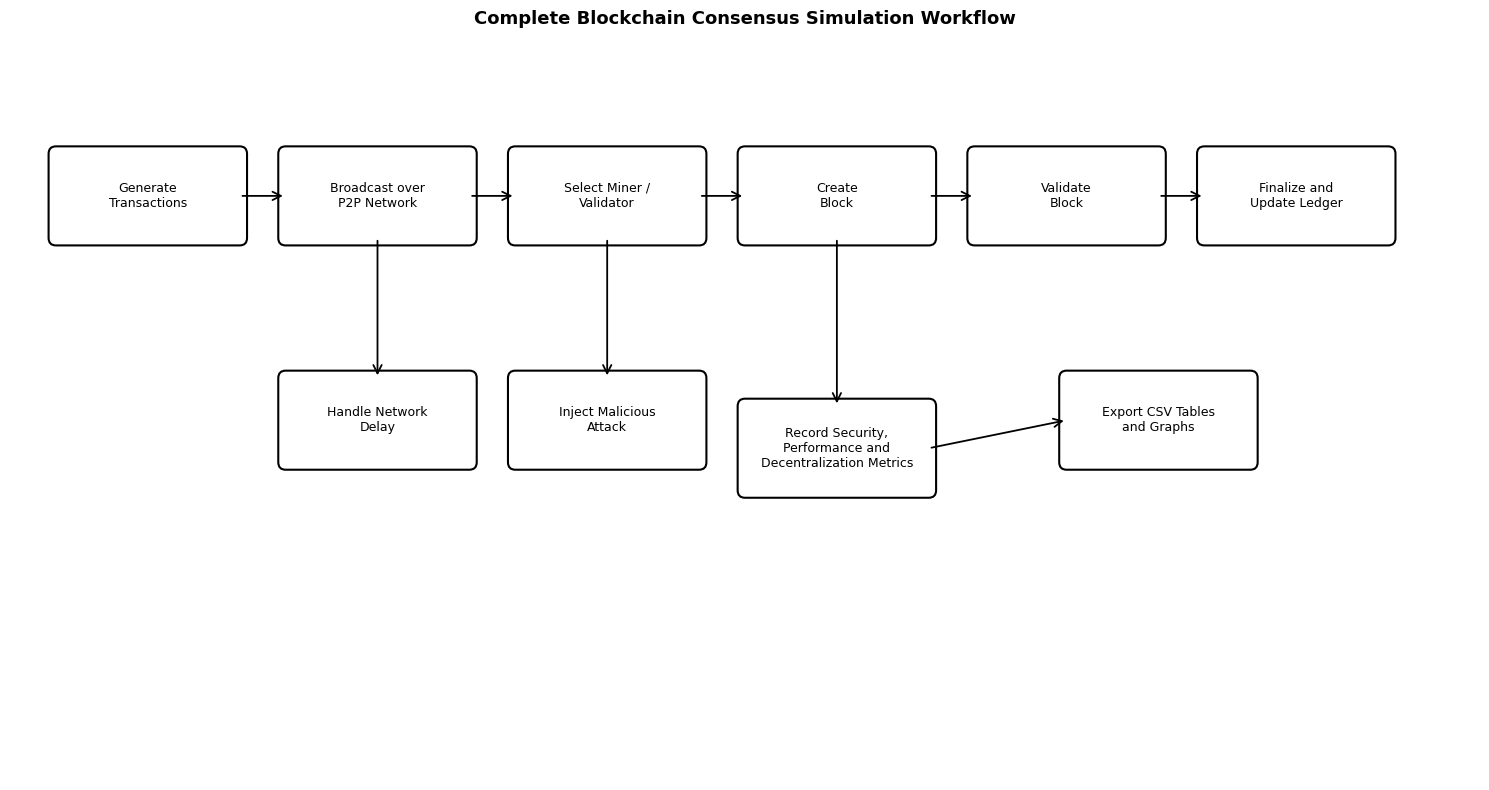

In [ ]:
# CELL 4D: Visualization of complete blockchain simulation workflow

def visualize_simulation_workflow():
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 8)
    ax.axis("off")

    steps = [
        ("Generate\nTransactions", 0.5, 5.8),
        ("Broadcast over\nP2P Network", 3.0, 5.8),
        ("Select Miner /\nValidator", 5.5, 5.8),
        ("Create\nBlock", 8.0, 5.8),
        ("Validate\nBlock", 10.5, 5.8),
        ("Finalize and\nUpdate Ledger", 13.0, 5.8),
        ("Handle Network\nDelay", 3.0, 3.4),
        ("Inject Malicious\nAttack", 5.5, 3.4),
        ("Record Security,\nPerformance and\nDecentralization Metrics", 8.0, 3.1),
        ("Export CSV Tables\nand Graphs", 11.5, 3.4)
    ]

    for text, x, y in steps:
        draw_box(ax, x, y, text, 2.0, 0.9)

    draw_arrow(ax, (2.5, 6.25), (3.0, 6.25))
    draw_arrow(ax, (5.0, 6.25), (5.5, 6.25))
    draw_arrow(ax, (7.5, 6.25), (8.0, 6.25))
    draw_arrow(ax, (10.0, 6.25), (10.5, 6.25))
    draw_arrow(ax, (12.5, 6.25), (13.0, 6.25))

    draw_arrow(ax, (4.0, 5.8), (4.0, 4.3))
    draw_arrow(ax, (6.5, 5.8), (6.5, 4.3))
    draw_arrow(ax, (9.0, 5.8), (9.0, 4.0))
    draw_arrow(ax, (10.0, 3.55), (11.5, 3.85))

    ax.set_title(
        "Complete Blockchain Consensus Simulation Workflow",
        fontsize=13,
        fontweight="bold"
    )

    path = f"{GRAPH_DIR}/architecture/full_simulation_workflow.png"
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()

visualize_simulation_workflow()

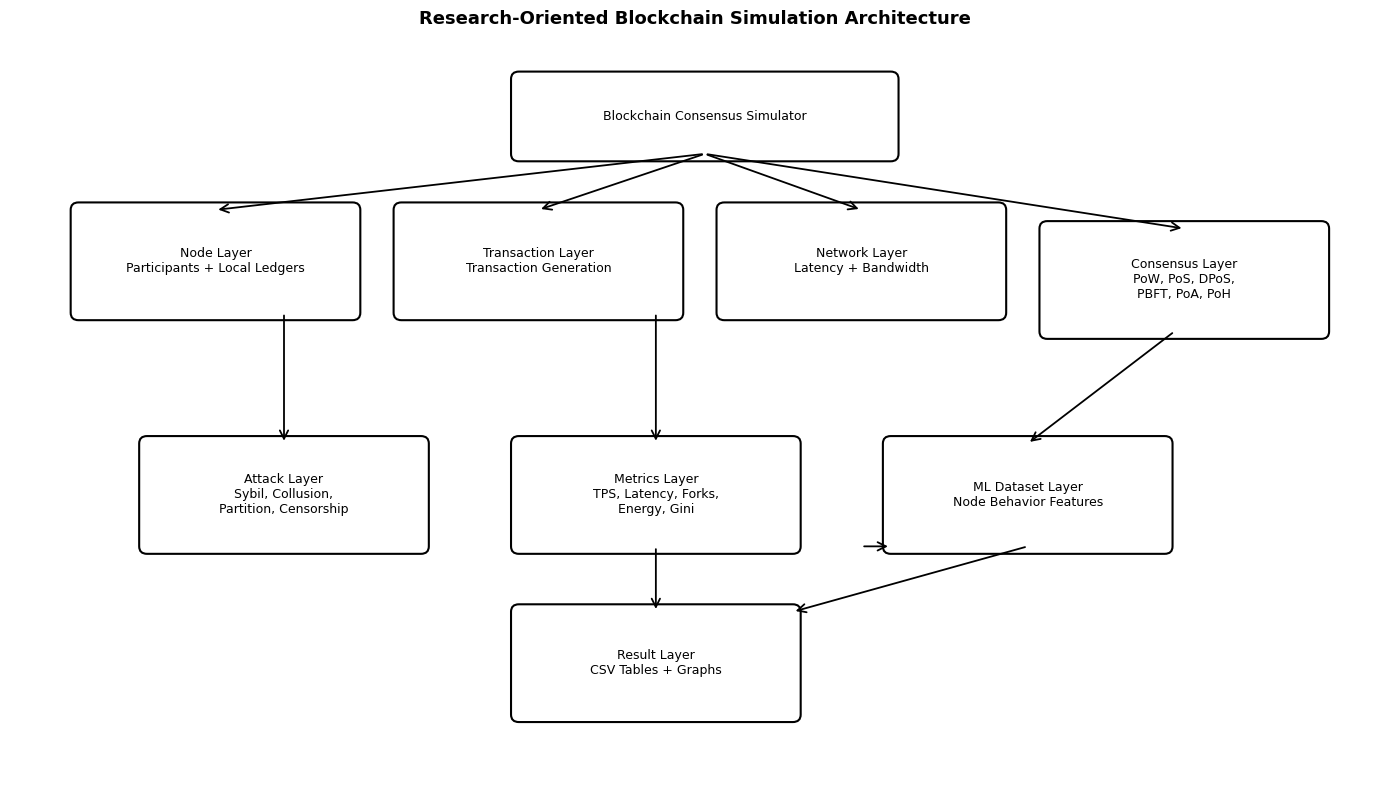

In [ ]:
# CELL 4E: Visualization of the complete simulator architecture

def visualize_simulator_architecture():
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 8)
    ax.axis("off")

    draw_box(ax, 5.2, 6.7, "Blockchain Consensus Simulator", 3.8, 0.8)

    modules = [
        ("Node Layer\nParticipants + Local Ledgers", 0.7, 5.0),
        ("Transaction Layer\nTransaction Generation", 4.0, 5.0),
        ("Network Layer\nLatency + Bandwidth", 7.3, 5.0),
        ("Consensus Layer\nPoW, PoS, DPoS,\nPBFT, PoA, PoH", 10.6, 4.8),
        ("Attack Layer\nSybil, Collusion,\nPartition, Censorship", 1.4, 2.5),
        ("Metrics Layer\nTPS, Latency, Forks,\nEnergy, Gini", 5.2, 2.5),
        ("ML Dataset Layer\nNode Behavior Features", 9.0, 2.5),
        ("Result Layer\nCSV Tables + Graphs", 5.2, 0.7)
    ]

    for text, x, y in modules:
        draw_box(ax, x, y, text, 2.8, 1.1)

    center = (7.1, 6.7)

    for _, x, y in modules[:4]:
        draw_arrow(ax, center, (x + 1.4, y + 1.1))

    draw_arrow(ax, (2.8, 5.0), (2.8, 3.6))
    draw_arrow(ax, (11.9, 4.8), (10.4, 3.6))
    draw_arrow(ax, (6.6, 5.0), (6.6, 3.6))
    draw_arrow(ax, (8.7, 2.5), (9.0, 2.5))
    draw_arrow(ax, (6.6, 2.5), (6.6, 1.8))
    draw_arrow(ax, (10.4, 2.5), (8.0, 1.8))

    ax.set_title(
        "Research-Oriented Blockchain Simulation Architecture",
        fontsize=13,
        fontweight="bold"
    )

    path = f"{GRAPH_DIR}/architecture/simulator_architecture.png"
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()

visualize_simulator_architecture()

In [ ]:
# CELL 5: Run enhanced experiments and generate both static and temporal node behavior datasets

consensus_mechanisms = ["PoW", "PoS", "DPoS", "PBFT", "PoA", "PoH"]
node_counts = [20, 50]
transaction_counts = [1000, 3000]
malicious_ratios = [0.1, 0.2, 0.3, 0.4]
attack_types = ["None", "Sybil", "Collusion", "NetworkPartition", "SelfishMining", "Censorship"]

all_results = []
all_node_features = []
all_temporal_features = []

class TemporalBlockchainSimulator(BlockchainSimulator):
    def __init__(
        self,
        *args,
        mining_difficulty=1.0,
        validator_weighting=1.0,
        slashing_severity=1.0,
        delegate_rotation_frequency=1.0,
        **kwargs
    ):
        super().__init__(*args, **kwargs)
        self.temporal_logs = []
        self.mining_difficulty = mining_difficulty
        self.validator_weighting = validator_weighting
        self.slashing_severity = slashing_severity
        self.delegate_rotation_frequency = delegate_rotation_frequency

    def select_proposer(self):
        if self.consensus == "PoW":
            powers = np.array([n.hash_power for n in self.nodes], dtype=float)
            probs = powers / (powers.sum() + 1e-9)
            return np.random.choice(self.nodes, p=probs)

        elif self.consensus == "PoS":
            stakes = np.array([n.stake for n in self.nodes], dtype=float)
            weighted_stakes = np.power(stakes + 1e-9, self.validator_weighting)
            probs = weighted_stakes / (weighted_stakes.sum() + 1e-9)
            return np.random.choice(self.nodes, p=probs)

        elif self.consensus == "DPoS":
            delegates = sorted(self.nodes, key=lambda n: n.delegate_votes, reverse=True)
            delegate_count = max(3, int(self.num_nodes * 0.1 * self.delegate_rotation_frequency))
            delegate_count = min(delegate_count, self.num_nodes)
            top_delegates = delegates[:delegate_count]
            return random.choice(top_delegates)

        elif self.consensus == "PBFT":
            return random.choice(self.nodes)

        elif self.consensus == "PoA":
            authorities = [n for n in self.nodes if n.authority]
            return random.choice(authorities)

        elif self.consensus == "PoH":
            return self.nodes[len(self.chain) % self.num_nodes]

        else:
            return random.choice(self.nodes)

    def apply_attack(self, proposer):
        success = super().apply_attack(proposer)

        if success and proposer.is_malicious:
            proposer.stake = max(1.0, proposer.stake - (10.0 * self.slashing_severity))
            proposer.validation_failure_count += int(max(1, round(self.slashing_severity)))

        return success

    def consensus_costs(self):
        base_latency = super().consensus_costs()

        if self.consensus == "PoW":
            base_latency *= self.mining_difficulty
            self.cpu_cost *= self.mining_difficulty
            self.energy_cost *= self.mining_difficulty

        elif self.consensus == "PoS":
            base_latency /= max(0.5, self.validator_weighting)

        elif self.consensus == "DPoS":
            base_latency /= max(0.5, self.delegate_rotation_frequency)

        return base_latency

    def log_temporal_node_behavior(self, round_id):
        for n in self.nodes:
            self.temporal_logs.append({
                "round": round_id,
                "consensus": self.consensus,
                "attack_type": self.attack_type,
                "node_id": n.node_id,
                "block_proposal_count": n.block_proposal_count,
                "invalid_block_count": n.invalid_block_count,
                "average_message_delay": n.avg_delay(),
                "fork_contribution_count": n.fork_contribution_count,
                "validation_failure_count": n.validation_failure_count,
                "missed_validation_count": n.missed_validation_count,
                "censorship_count": n.censorship_count,
                "peer_disconnect_count": n.peer_disconnect_count,
                "stake_change_rate": n.stake_change_rate,
                "hash_power": n.hash_power,
                "stake": n.stake,
                "delegate_votes": n.delegate_votes,
                "is_authority": int(n.authority),
                "label": int(n.is_malicious)
            })

    def run(self):
        total_finalized_tx = 0

        for r in range(self.rounds):
            self.generate_transactions()
            proposer = self.select_proposer()
            proposer.block_proposal_count += 1

            avg_delay = self.simulate_network_delay()
            latency_factor = self.consensus_costs()
            attack_success = self.apply_attack(proposer)

            block_size = min(len(self.pending_transactions), random.randint(20, 100))
            block_txs = self.pending_transactions[:block_size]

            valid = self.validate_block(proposer)

            if valid and not attack_success:
                prev_hash = self.chain[-1].block_hash
                block = Block(
                    block_id=f"{self.consensus}_{r}_{time.time()}",
                    proposer_id=proposer.node_id,
                    previous_hash=prev_hash,
                    transactions=block_txs,
                    timestamp=time.time(),
                    consensus=self.consensus
                )

                if self.consensus == "PoW":
                    block.nonce = random.randint(1000, 999999)

                if self.consensus == "PoH":
                    block.timestamp = r

                block.block_hash = block.compute_hash()
                self.chain.append(block)

                proposer.ledger.append(block)
                self.pending_transactions = self.pending_transactions[block_size:]

                total_finalized_tx += len(block_txs)
                confirmation_latency = avg_delay * latency_factor
                self.confirmation_latencies.append(confirmation_latency)

                if self.consensus == "PoW" and np.random.rand() < 0.08:
                    self.fork_count += 1
                    proposer.fork_contribution_count += 1

                if self.consensus == "PoS":
                    proposer.stake += random.uniform(0.1, 2.0)
                    proposer.stake_change_rate += random.uniform(0.01, 0.05)

            else:
                self.failed_finalizations += 1

            self.log_temporal_node_behavior(r)

        avg_latency = np.mean(self.confirmation_latencies) if self.confirmation_latencies else 0
        throughput = total_finalized_tx / max(1e-6, np.sum(self.confirmation_latencies) + 1)

        values = self.get_distribution_values()
        gini = gini_coefficient(values)
        concentration = validator_concentration(values)

        result = {
            "consensus": self.consensus,
            "num_nodes": self.num_nodes,
            "num_transactions": self.num_transactions,
            "malicious_ratio": self.malicious_ratio,
            "attack_type": self.attack_type,
            "throughput_tps": throughput,
            "confirmation_latency": avg_latency,
            "fork_rate": self.fork_count / max(1, len(self.chain)),
            "cpu_cost": self.cpu_cost,
            "energy_cost": self.energy_cost,
            "bandwidth_usage": self.bandwidth_usage,
            "storage_growth": len(self.chain) * 1.2,
            "attack_success_rate": self.attack_success_count / max(1, self.rounds),
            "failed_finalization_rate": self.failed_finalizations / max(1, self.rounds),
            "gini_coefficient": gini,
            "validator_concentration": concentration,
            "chain_length": len(self.chain),
            "mining_difficulty": self.mining_difficulty,
            "validator_weighting": self.validator_weighting,
            "slashing_severity": self.slashing_severity,
            "delegate_rotation_frequency": self.delegate_rotation_frequency
        }

        return result

for consensus in consensus_mechanisms:
    for nodes in node_counts:
        for txs in transaction_counts:
            for attack in attack_types:
                for mr in malicious_ratios:
                    if attack == "None" and mr != 0.1:
                        continue

                    sim = TemporalBlockchainSimulator(
                        consensus=consensus,
                        num_nodes=nodes,
                        num_transactions=txs,
                        malicious_ratio=mr,
                        attack_type=attack,
                        rounds=30
                    )

                    result = sim.run()
                    all_results.append(result)
                    all_node_features.append(sim.extract_node_features())
                    all_temporal_features.append(pd.DataFrame(sim.temporal_logs))

results_df = pd.DataFrame(all_results)
node_features_df = pd.concat(all_node_features, ignore_index=True)
temporal_features_df = pd.concat(all_temporal_features, ignore_index=True)

results_df.to_csv(f"{RESULT_DIR}/consensus_comparative_results.csv", index=False)
node_features_df.to_csv(f"{RESULT_DIR}/node_behavior_dataset.csv", index=False)
temporal_features_df.to_csv(f"{RESULT_DIR}/temporal_node_behavior_dataset.csv", index=False)

display(results_df.head())
display(node_features_df.head())
display(temporal_features_df.head())


,consensus,num_nodes,num_transactions,malicious_ratio,attack_type,throughput_tps,confirmation_latency,fork_rate,cpu_cost,energy_cost,...,storage_growth,attack_success_rate,failed_finalization_rate,gini_coefficient,validator_concentration,chain_length,mining_difficulty,validator_weighting,slashing_severity,delegate_rotation_frequency
0,PoW,20,1000,0.1,None,72.247082,0.418819,0.032258,4561.823739,7167.322710,...,37.2,0.000000,0.000000,0.496106,0.348896,31,1.0,1.0,1.0,1.0
1,PoW,20,1000,0.1,Sybil,74.970753,0.420867,0.133333,4272.802782,6930.052634,...,36.0,0.000000,0.033333,0.432436,0.248534,30,1.0,1.0,1.0,1.0
2,PoW,20,1000,0.2,Sybil,66.608275,0.462101,0.064516,4463.157626,6976.438277,...,37.2,0.000000,0.000000,0.452646,0.260372,31,1.0,1.0,1.0,1.0
3,PoW,20,1000,0.3,Sybil,67.169762,0.508844,0.035714,4628.569055,7204.470988,...,33.6,0.066667,0.100000,0.535814,0.329955,28,1.0,1.0,1.0,1.0
4,PoW,20,1000,0.4,Sybil,77.806886,0.509731,0.041667,4456.678008,7278.584294,...,28.8,0.166667,0.233333,0.539583,0.340185,24,1.0,1.0,1.0,1.0


,consensus,attack_type,node_id,block_proposal_count,invalid_block_count,average_message_delay,fork_contribution_count,validation_failure_count,missed_validation_count,censorship_count,peer_disconnect_count,stake_change_rate,hash_power,stake,delegate_votes,is_authority,label
0,PoW,None,0,2,0,0.072122,0,0,0,0,0,0.0,0.469268,301.012143,0.0,0,0
1,PoW,None,1,3,0,0.103956,0,0,0,0,0,0.0,1.316746,91.294255,0.0,0,0
2,PoW,None,2,2,0,0.100914,0,0,0,0,0,0.0,0.169625,16.959629,0.0,0,0
3,PoW,None,3,0,0,0.075678,0,0,0,0,0,0.0,0.059839,201.123086,0.0,0,0
4,PoW,None,4,4,0,0.049726,0,0,0,0,0,0.0,0.919082,123.125006,0.0,0,0


,round,consensus,attack_type,node_id,block_proposal_count,invalid_block_count,average_message_delay,fork_contribution_count,validation_failure_count,missed_validation_count,censorship_count,peer_disconnect_count,stake_change_rate,hash_power,stake,delegate_votes,is_authority,label
0,0,PoW,None,0,0,0,0.001000,0,0,0,0,0,0.0,0.469268,301.012143,0.0,0,0
1,0,PoW,None,1,0,0,0.049171,0,0,0,0,0,0.0,1.316746,91.294255,0.0,0,0
2,0,PoW,None,2,1,0,0.015582,0,0,0,0,0,0.0,0.169625,16.959629,0.0,0,0
3,0,PoW,None,3,0,0,0.108402,0,0,0,0,0,0.0,0.059839,201.123086,0.0,0,0
4,0,PoW,None,4,0,0,0.001000,0,0,0,0,0,0.0,0.919082,123.125006,0.0,0,0


In [ ]:
#Cell 6: Create manuscript result tables
# Aggregate simulation outputs into performance, security, and decentralization summary tables suitable for research analysis and manuscript reporting.
performance_table = results_df.groupby("consensus").agg({
    "throughput_tps": "mean",
    "confirmation_latency": "mean",
    "fork_rate": "mean",
    "bandwidth_usage": "mean",
    "cpu_cost": "mean",
    "energy_cost": "mean"
}).reset_index()

security_table = results_df.groupby("consensus").agg({
    "attack_success_rate": "mean",
    "failed_finalization_rate": "mean",
    "fork_rate": "mean"
}).reset_index()

decentralization_table = results_df.groupby("consensus").agg({
    "gini_coefficient": "mean",
    "validator_concentration": "mean"
}).reset_index()

performance_table.to_csv(f"{RESULT_DIR}/performance_table.csv", index=False)
security_table.to_csv(f"{RESULT_DIR}/security_table.csv", index=False)
decentralization_table.to_csv(f"{RESULT_DIR}/decentralization_table.csv", index=False)

print("Performance Table")
display(performance_table)

print("Security Table")
display(security_table)

print("Decentralization Table")
display(decentralization_table)

Performance Table


,consensus,throughput_tps,confirmation_latency,fork_rate,bandwidth_usage,cpu_cost,energy_cost
0,DPoS,263.268970,0.149454,0.066312,525.0,1208.055576,735.149118
1,PBFT,89.829922,0.290904,0.482985,960.0,3142.439625,1584.050875
2,PoA,335.397924,0.107971,0.070392,525.0,787.396830,527.369323
3,PoH,306.035590,0.125072,0.073496,525.0,1573.754363,1203.869000
4,PoS,220.410118,0.190088,0.069733,525.0,1572.313631,1054.139383
5,PoW,97.761424,0.474575,0.163432,525.0,7871.871982,12094.158278


Security Table


,consensus,attack_success_rate,failed_finalization_rate,fork_rate
0,DPoS,0.115079,0.167063,0.066312
1,PBFT,0.121032,0.573413,0.482985
2,PoA,0.127778,0.186905,0.070392
3,PoH,0.142460,0.194048,0.073496
4,PoS,0.121032,0.157143,0.069733
5,PoW,0.147619,0.190079,0.163432


Decentralization Table


,consensus,gini_coefficient,validator_concentration
0,DPoS,0.477413,0.308690
1,PBFT,0.000000,0.100000
2,PoA,0.855000,0.690476
3,PoH,0.000000,0.100000
4,PoS,0.480752,0.314584
5,PoW,0.474505,0.310682


In [ ]:
#Cell 7: ML-based malicious node detection
# Train and evaluate supervised machine learning models to classify nodes as honest or malicious using features extracted from simulated blockchain behavior.
feature_columns = [
    "block_proposal_count",
    "invalid_block_count",
    "average_message_delay",
    "fork_contribution_count",
    "validation_failure_count",
    "missed_validation_count",
    "censorship_count",
    "peer_disconnect_count",
    "stake_change_rate",
    "hash_power",
    "stake",
    "delegate_votes",
    "is_authority"
]

X = node_features_df[feature_columns].fillna(0)
y = node_features_df["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=SEED, stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "MLP Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED)
}

ml_results = []
roc_data = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = preds

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    try:
        auc = roc_auc_score(y_test, probs)
    except:
        auc = 0

    ml_results.append({
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": auc
    })

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_data[name] = (fpr, tpr)

ml_results_df = pd.DataFrame(ml_results)
ml_results_df.to_csv(f"{RESULT_DIR}/ml_detection_results.csv", index=False)

print("ML Detection Results")
display(ml_results_df)

ML Detection Results


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.993651,0.998090,0.975724,0.986780,0.998794
1,Random Forest,0.993197,0.994302,0.977591,0.985876,0.997113
2,Gradient Boosting,0.992517,0.989623,0.979458,0.984514,0.998198
3,MLP Neural Network,0.993878,0.995256,0.979458,0.987294,0.998244


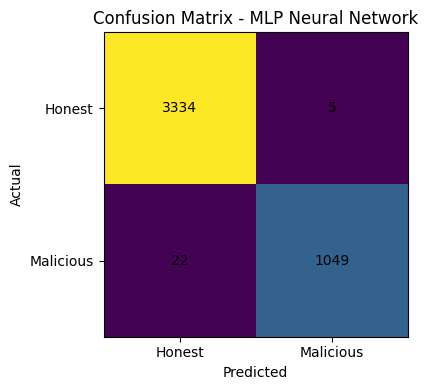

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3339
           1       1.00      0.98      0.99      1071

    accuracy                           0.99      4410
   macro avg       0.99      0.99      0.99      4410
weighted avg       0.99      0.99      0.99      4410



In [ ]:
#Cell 8: Confusion matrix for best ML model
# Identify the best-performing supervised model and visualize its classification performance using a confusion matrix and detailed evaluation metrics.
best_model_name = ml_results_df.sort_values("f1_score", ascending=False).iloc[0]["model"]
best_model = models[best_model_name]

best_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Honest", "Malicious"])
plt.yticks([0, 1], ["Honest", "Malicious"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/confusion_matrix_best_model.png", dpi=300)
plt.show()

print(classification_report(y_test, best_preds))

In [ ]:
#Cell 9: Unsupervised anomaly detection
# Apply unsupervised learning algorithms to discover abnormal node behavior patterns and assess their clustering effectiveness without requiring labeled data.
kmeans = KMeans(n_clusters=2, random_state=SEED)
kmeans_labels = kmeans.fit_predict(X_scaled)

try:
    kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
except:
    kmeans_silhouette = 0

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

try:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
except:
    dbscan_silhouette = 0

unsupervised_results = pd.DataFrame([
    {
        "model": "K-Means",
        "silhouette_score": kmeans_silhouette,
        "detected_clusters": len(set(kmeans_labels))
    },
    {
        "model": "DBSCAN",
        "silhouette_score": dbscan_silhouette,
        "detected_clusters": len(set(dbscan_labels))
    }
])

unsupervised_results.to_csv(f"{RESULT_DIR}/unsupervised_detection_results.csv", index=False)

display(unsupervised_results)

,model,silhouette_score,detected_clusters
0,K-Means,0.650732,2
1,DBSCAN,0.141066,34


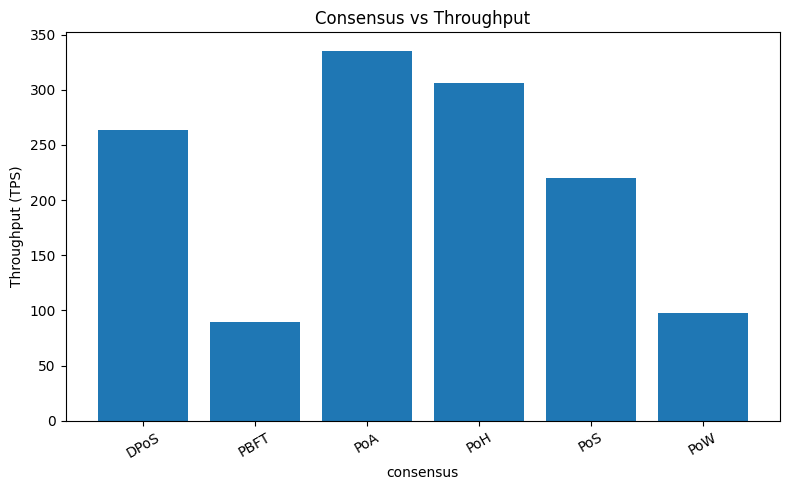

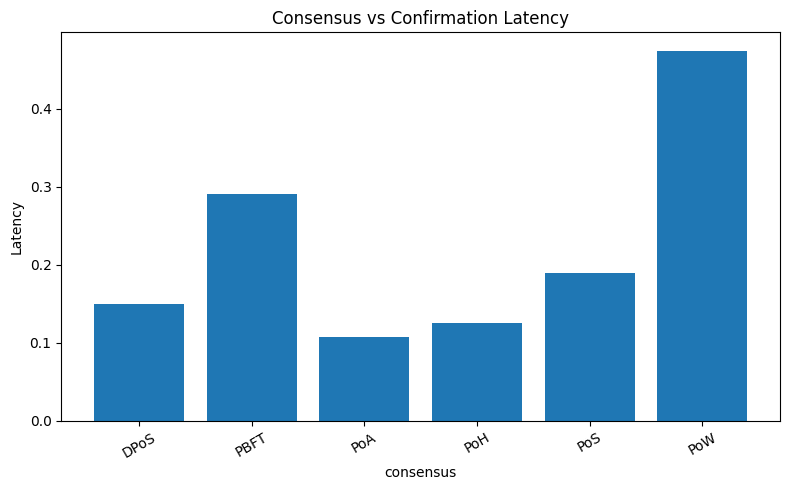

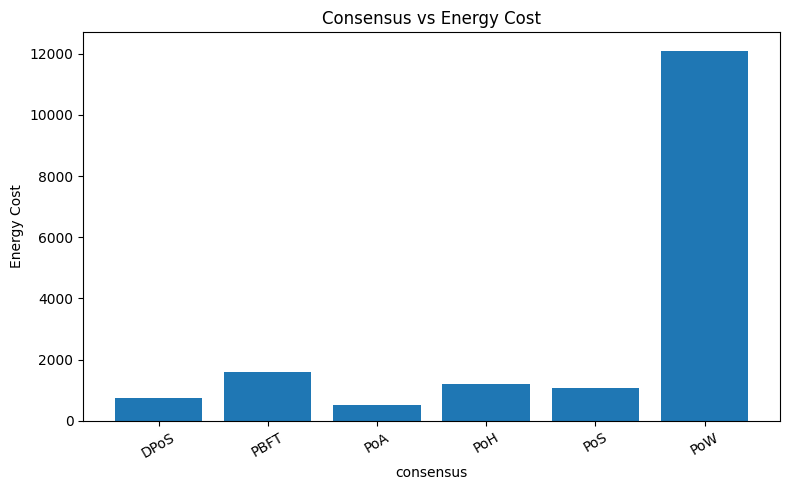

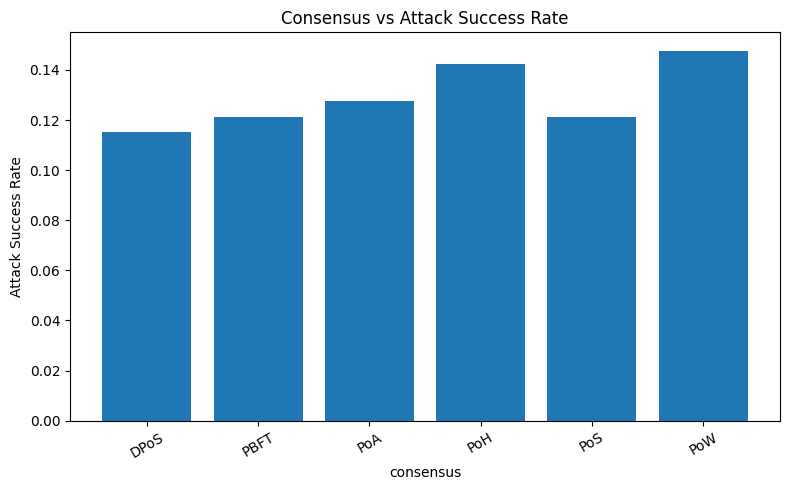

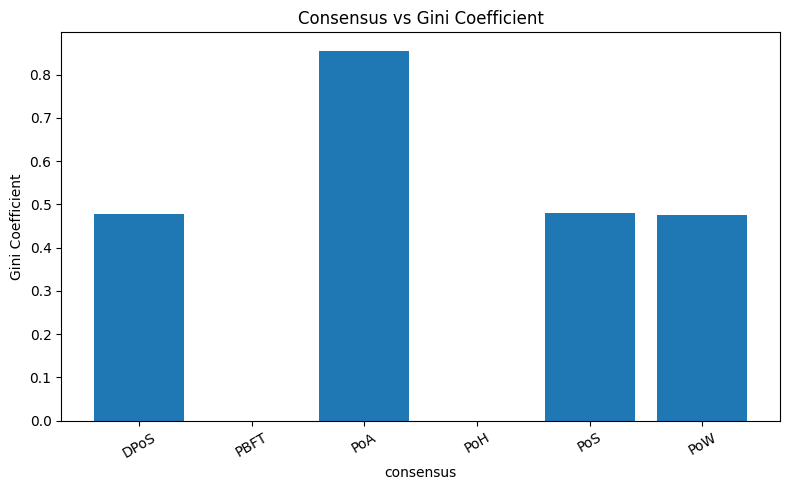

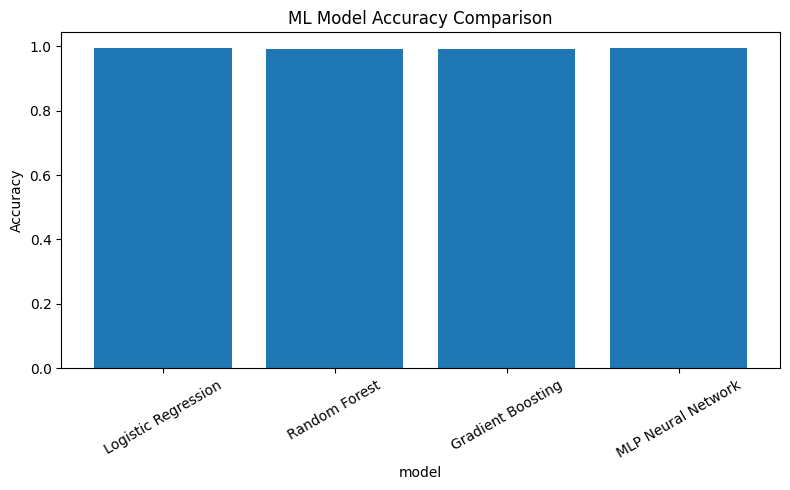

In [ ]:
#Cell 10: Generate manuscript graphs
# Create comparative visualization plots illustrating performance, security, decentralization, and machine learning results across different consensus mechanisms.
def save_bar_graph(df, x_col, y_col, title, ylabel, filename):
    plt.figure(figsize=(8, 5))
    plt.bar(df[x_col], df[y_col])
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(ylabel)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"{GRAPH_DIR}/{filename}", dpi=300)
    plt.show()

save_bar_graph(
    performance_table,
    "consensus",
    "throughput_tps",
    "Consensus vs Throughput",
    "Throughput (TPS)",
    "consensus_vs_throughput.png"
)

save_bar_graph(
    performance_table,
    "consensus",
    "confirmation_latency",
    "Consensus vs Confirmation Latency",
    "Latency",
    "consensus_vs_latency.png"
)

save_bar_graph(
    performance_table,
    "consensus",
    "energy_cost",
    "Consensus vs Energy Cost",
    "Energy Cost",
    "consensus_vs_energy_cost.png"
)

save_bar_graph(
    security_table,
    "consensus",
    "attack_success_rate",
    "Consensus vs Attack Success Rate",
    "Attack Success Rate",
    "consensus_vs_attack_success_rate.png"
)

save_bar_graph(
    decentralization_table,
    "consensus",
    "gini_coefficient",
    "Consensus vs Gini Coefficient",
    "Gini Coefficient",
    "consensus_vs_gini.png"
)

save_bar_graph(
    ml_results_df,
    "model",
    "accuracy",
    "ML Model Accuracy Comparison",
    "Accuracy",
    "ml_accuracy_comparison.png"
)

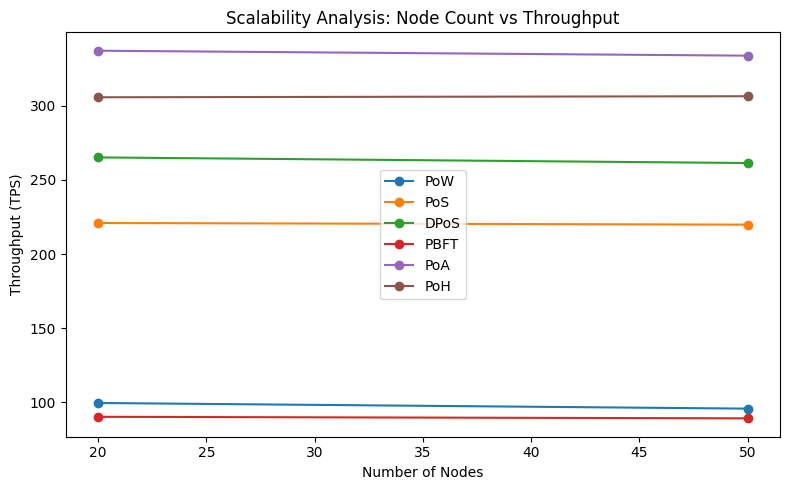

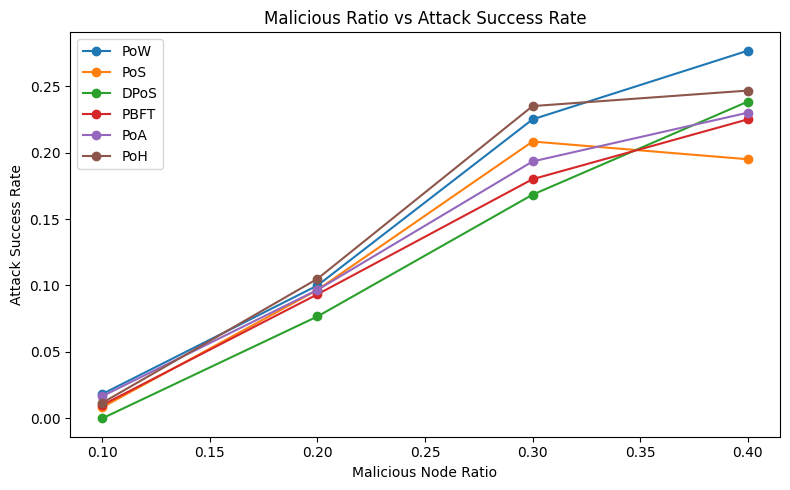

In [ ]:
#Cell 11: Scalability and attack graphs
# Analyze the impact of increasing network size and malicious participation on throughput, scalability, and attack success across consensus protocols.
scalability_df = results_df.groupby(["consensus", "num_nodes"]).agg({
    "throughput_tps": "mean",
    "confirmation_latency": "mean"
}).reset_index()

plt.figure(figsize=(8, 5))
for consensus in consensus_mechanisms:
    temp = scalability_df[scalability_df["consensus"] == consensus]
    plt.plot(temp["num_nodes"], temp["throughput_tps"], marker="o", label=consensus)

plt.title("Scalability Analysis: Node Count vs Throughput")
plt.xlabel("Number of Nodes")
plt.ylabel("Throughput (TPS)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/scalability_node_count_vs_throughput.png", dpi=300)
plt.show()

attack_df = results_df[results_df["attack_type"] != "None"].groupby(
    ["malicious_ratio", "consensus"]
).agg({
    "attack_success_rate": "mean"
}).reset_index()

plt.figure(figsize=(8, 5))
for consensus in consensus_mechanisms:
    temp = attack_df[attack_df["consensus"] == consensus]
    plt.plot(temp["malicious_ratio"], temp["attack_success_rate"], marker="o", label=consensus)

plt.title("Malicious Ratio vs Attack Success Rate")
plt.xlabel("Malicious Node Ratio")
plt.ylabel("Attack Success Rate")
plt.legend()
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/malicious_ratio_vs_attack_success.png", dpi=300)
plt.show()

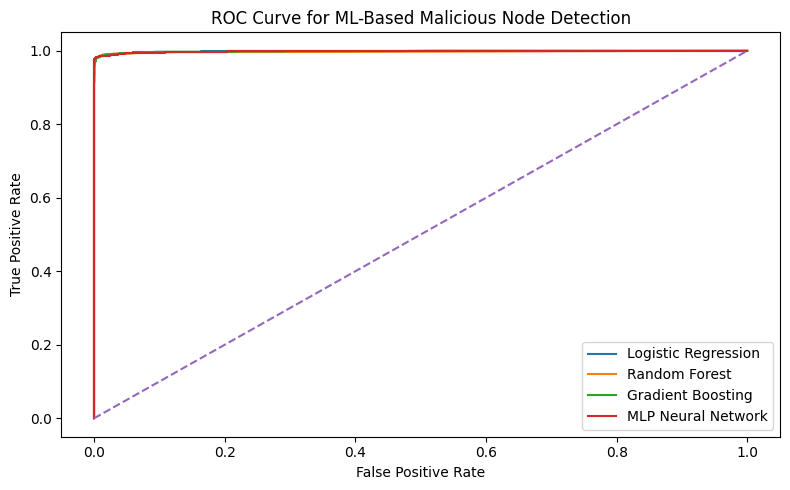

In [ ]:
#Cell 12: ROC curves
# Generate ROC curves to compare the discrimination capability of supervised machine learning models for malicious node detection.
plt.figure(figsize=(8, 5))

for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve for ML-Based Malicious Node Detection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/roc_curve_ml_models.png", dpi=300)
plt.show()

In [ ]:
#Cell 13: Create final summary table
# Consolidate all major simulation metrics into a single comprehensive summary table for comparative analysis and manuscript presentation.
summary_table = results_df.groupby("consensus").agg({
    "throughput_tps": "mean",
    "confirmation_latency": "mean",
    "fork_rate": "mean",
    "attack_success_rate": "mean",
    "failed_finalization_rate": "mean",
    "gini_coefficient": "mean",
    "validator_concentration": "mean",
    "cpu_cost": "mean",
    "energy_cost": "mean",
    "bandwidth_usage": "mean"
}).reset_index()

summary_table.to_csv(f"{RESULT_DIR}/final_manuscript_summary_table.csv", index=False)

display(summary_table)

,consensus,throughput_tps,confirmation_latency,fork_rate,attack_success_rate,failed_finalization_rate,gini_coefficient,validator_concentration,cpu_cost,energy_cost,bandwidth_usage
0,DPoS,263.268970,0.149454,0.066312,0.115079,0.167063,0.477413,0.308690,1208.055576,735.149118,525.0
1,PBFT,89.829922,0.290904,0.482985,0.121032,0.573413,0.000000,0.100000,3142.439625,1584.050875,960.0
2,PoA,335.397924,0.107971,0.070392,0.127778,0.186905,0.855000,0.690476,787.396830,527.369323,525.0
3,PoH,306.035590,0.125072,0.073496,0.142460,0.194048,0.000000,0.100000,1573.754363,1203.869000,525.0
4,PoS,220.410118,0.190088,0.069733,0.121032,0.157143,0.480752,0.314584,1572.313631,1054.139383,525.0
5,PoW,97.761424,0.474575,0.163432,0.147619,0.190079,0.474505,0.310682,7871.871982,12094.158278,525.0


In [ ]:
# CELL 15: Hyperparameter optimization for supervised malicious-node detection models

from sklearn.model_selection import RandomizedSearchCV

feature_columns = [
    "block_proposal_count",
    "invalid_block_count",
    "average_message_delay",
    "fork_contribution_count",
    "validation_failure_count",
    "missed_validation_count",
    "censorship_count",
    "peer_disconnect_count",
    "stake_change_rate",
    "hash_power",
    "stake",
    "delegate_votes",
    "is_authority"
]

X = node_features_df[feature_columns].fillna(0)
y = node_features_df["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

optimized_models = {
    "Random Forest": (
        RandomForestClassifier(random_state=SEED),
        {
            "n_estimators": [100, 150, 200, 300],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=SEED),
        {
            "n_estimators": [100, 150, 200],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "max_depth": [2, 3, 4, 5]
        }
    ),
    "MLP Neural Network": (
        MLPClassifier(max_iter=500, random_state=SEED),
        {
            "hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
            "activation": ["relu", "tanh"],
            "alpha": [0.0001, 0.001, 0.01],
            "learning_rate_init": [0.001, 0.005, 0.01]
        }
    )
}

optimized_results = []
best_optimized_models = {}

for model_name, (model, param_grid) in optimized_models.items():
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=8,
        scoring="f1",
        cv=3,
        random_state=SEED,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    best_optimized_models[model_name] = best_model

    preds = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        probs = best_model.predict_proba(X_test)[:, 1]
    else:
        probs = preds

    optimized_results.append({
        "model": model_name,
        "best_parameters": str(search.best_params_),
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1_score": f1_score(y_test, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probs)
    })

optimized_ml_results_df = pd.DataFrame(optimized_results)
optimized_ml_results_df.to_csv(f"{RESULT_DIR}/optimized_supervised_ml_results.csv", index=False)

display(optimized_ml_results_df)

,model,best_parameters,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,"{'n_estimators': 200, 'min_samples_split': 10,...",0.993878,0.997143,0.977591,0.987270,0.998115
1,Gradient Boosting,"{'n_estimators': 100, 'max_depth': 2, 'learnin...",0.993197,0.993365,0.978525,0.985889,0.997858
2,MLP Neural Network,"{'learning_rate_init': 0.005, 'hidden_layer_si...",0.993651,0.998090,0.975724,0.986780,0.998057


In [ ]:
# CELL 16: Prepare temporal node behavior sequences for GRU models

temporal_feature_columns = [
    "block_proposal_count",
    "invalid_block_count",
    "average_message_delay",
    "fork_contribution_count",
    "validation_failure_count",
    "missed_validation_count",
    "censorship_count",
    "peer_disconnect_count",
    "stake_change_rate",
    "hash_power",
    "stake",
    "delegate_votes",
    "is_authority"
]

def create_temporal_sequences(df, sequence_length=10):
    X_seq = []
    y_seq = []

    group_cols = ["consensus", "attack_type", "node_id"]

    for _, group in df.groupby(group_cols):
        group = group.sort_values("round")

        if len(group) < sequence_length:
            continue

        features = group[temporal_feature_columns].fillna(0).values
        labels = group["label"].values

        for i in range(len(group) - sequence_length + 1):
            X_seq.append(features[i:i + sequence_length])
            y_seq.append(labels[i + sequence_length - 1])

    return np.array(X_seq), np.array(y_seq)

sequence_length = 10

X_seq, y_seq = create_temporal_sequences(
    temporal_features_df,
    sequence_length=sequence_length
)

if X_seq.size == 0:
    raise ValueError("No temporal sequences were created. Increase simulator rounds or reduce sequence_length.")

num_samples, seq_len, num_features = X_seq.shape

X_seq_reshaped = X_seq.reshape(-1, num_features)
seq_scaler = StandardScaler()
X_seq_scaled = seq_scaler.fit_transform(X_seq_reshaped)
X_seq_scaled = X_seq_scaled.reshape(num_samples, seq_len, num_features)

X_seq_train, X_seq_test, y_seq_train, y_seq_test = train_test_split(
    X_seq_scaled,
    y_seq,
    test_size=0.25,
    random_state=SEED,
    stratify=y_seq
)

print("Temporal sequence dataset shape:", X_seq_scaled.shape)
print("Training sequences:", X_seq_train.shape)
print("Testing sequences:", X_seq_test.shape)

Temporal sequence dataset shape: (513000, 10, 13)
Training sequences: (384750, 10, 13)
Testing sequences: (128250, 10, 13)


In [ ]:
# CELL 17: GRU-based temporal attack detection with hyperparameter optimization

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(SEED)

def build_gru_model(units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential()
    model.add(GRU(units, input_shape=(sequence_length, num_features)))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

gru_param_grid = [
    {"units": 32, "dropout": 0.2, "learning_rate": 0.001, "batch_size": 32},
    {"units": 64, "dropout": 0.2, "learning_rate": 0.001, "batch_size": 32},
    {"units": 64, "dropout": 0.3, "learning_rate": 0.001, "batch_size": 64},
    {"units": 128, "dropout": 0.3, "learning_rate": 0.0005, "batch_size": 64}
]

best_gru_f1 = -1
best_gru_model = None
best_gru_params = None

for params in gru_param_grid:
    model = build_gru_model(
        units=params["units"],
        dropout=params["dropout"],
        learning_rate=params["learning_rate"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    model.fit(
        X_seq_train,
        y_seq_train,
        validation_split=0.2,
        epochs=15,
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    probs = model.predict(X_seq_test, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)

    current_f1 = f1_score(y_seq_test, preds, zero_division=0)

    if current_f1 > best_gru_f1:
        best_gru_f1 = current_f1
        best_gru_model = model
        best_gru_params = params

gru_probs = best_gru_model.predict(X_seq_test, verbose=0).flatten()
gru_preds = (gru_probs >= 0.5).astype(int)

gru_results_df = pd.DataFrame([{
    "model": "GRU",
    "best_parameters": str(best_gru_params),
    "accuracy": accuracy_score(y_seq_test, gru_preds),
    "precision": precision_score(y_seq_test, gru_preds, zero_division=0),
    "recall": recall_score(y_seq_test, gru_preds, zero_division=0),
    "f1_score": f1_score(y_seq_test, gru_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_seq_test, gru_probs)
}])

gru_results_df.to_csv(f"{RESULT_DIR}/gru_temporal_detection_results.csv", index=False)

display(gru_results_df)

,model,best_parameters,accuracy,precision,recall,f1_score,roc_auc
0,GRU,"{'units': 32, 'dropout': 0.2, 'learning_rate':...",0.949981,0.935304,0.853346,0.892447,0.974855


In [23]:
# CELL 18: Reinforcement learning using Q-Learning to adapt consensus parameters

class ConsensusQAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}

    def get_state_key(self, state):
        return tuple(state)

    def choose_action(self, state):
        state_key = self.get_state_key(state)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(len(self.actions))

        if np.random.rand() < self.epsilon:
            return random.randint(0, len(self.actions) - 1)

        return int(np.argmax(self.q_table[state_key]))

    def update(self, state, action, reward, next_state):
        state_key = self.get_state_key(state)
        next_state_key = self.get_state_key(next_state)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(len(self.actions))

        if next_state_key not in self.q_table:
            self.q_table[next_state_key] = np.zeros(len(self.actions))

        old_value = self.q_table[state_key][action]
        next_max = np.max(self.q_table[next_state_key])

        new_value = old_value + self.alpha * (
            reward + self.gamma * next_max - old_value
        )

        self.q_table[state_key][action] = new_value

def discretize_state(result):
    throughput_level = int(min(4, result["throughput_tps"] // 10))
    attack_level = int(min(4, result["attack_success_rate"] * 10))
    decentralization_level = int(min(4, result["gini_coefficient"] * 5))
    latency_level = int(min(4, result["confirmation_latency"] * 10))

    return [
        throughput_level,
        attack_level,
        decentralization_level,
        latency_level
    ]

def compute_rl_reward(result):
    throughput_score = result["throughput_tps"]
    security_penalty = result["attack_success_rate"] * 50
    decentralization_penalty = result["gini_coefficient"] * 20
    latency_penalty = result["confirmation_latency"] * 10
    fork_penalty = result["fork_rate"] * 30

    reward = (
        throughput_score
        - security_penalty
        - decentralization_penalty
        - latency_penalty
        - fork_penalty
    )

    return reward

actions = [
    {
        "action_name": "Increase Mining Difficulty",
        "mining_difficulty": 1.5,
        "validator_weighting": 1.0,
        "slashing_severity": 1.0,
        "delegate_rotation_frequency": 1.0
    },
    {
        "action_name": "Increase Validator Weighting",
        "mining_difficulty": 1.0,
        "validator_weighting": 1.5,
        "slashing_severity": 1.0,
        "delegate_rotation_frequency": 1.0
    },
    {
        "action_name": "Increase Slashing Severity",
        "mining_difficulty": 1.0,
        "validator_weighting": 1.0,
        "slashing_severity": 1.5,
        "delegate_rotation_frequency": 1.0
    },
    {
        "action_name": "Increase Delegate Rotation",
        "mining_difficulty": 1.0,
        "validator_weighting": 1.0,
        "slashing_severity": 1.0,
        "delegate_rotation_frequency": 1.5
    },
    {
        "action_name": "Balanced Parameters",
        "mining_difficulty": 1.0,
        "validator_weighting": 1.0,
        "slashing_severity": 1.0,
        "delegate_rotation_frequency": 1.0
    }
]

q_agent = ConsensusQAgent(actions=actions, alpha=0.1, gamma=0.9, epsilon=0.25)

rl_logs = []

for episode in range(40):
    consensus = random.choice(consensus_mechanisms)
    attack = random.choice(["Sybil", "Collusion", "NetworkPartition", "Censorship"])
    malicious_ratio = random.choice([0.1, 0.2, 0.3, 0.4])

    baseline_sim = TemporalBlockchainSimulator(
        consensus=consensus,
        num_nodes=50,
        num_transactions=2000,
        malicious_ratio=malicious_ratio,
        attack_type=attack,
        rounds=10
    )

    baseline_result = baseline_sim.run()
    state = discretize_state(baseline_result)

    action_index = q_agent.choose_action(state)
    action = actions[action_index]

    adaptive_sim = TemporalBlockchainSimulator(
        consensus=consensus,
        num_nodes=50,
        num_transactions=2000,
        malicious_ratio=malicious_ratio,
        attack_type=attack,
        rounds=25,
        mining_difficulty=action["mining_difficulty"],
        validator_weighting=action["validator_weighting"],
        slashing_severity=action["slashing_severity"],
        delegate_rotation_frequency=action["delegate_rotation_frequency"]
    )

    adaptive_result = adaptive_sim.run()
    reward = compute_rl_reward(adaptive_result)
    next_state = discretize_state(adaptive_result)

    q_agent.update(state, action_index, reward, next_state)

    rl_logs.append({
        "episode": episode + 1,
        "consensus": consensus,
        "attack_type": attack,
        "malicious_ratio": malicious_ratio,
        "selected_action": action["action_name"],
        "reward": reward,
        "throughput_tps": adaptive_result["throughput_tps"],
        "attack_success_rate": adaptive_result["attack_success_rate"],
        "gini_coefficient": adaptive_result["gini_coefficient"],
        "confirmation_latency": adaptive_result["confirmation_latency"],
        "fork_rate": adaptive_result["fork_rate"]
    })

rl_results_df = pd.DataFrame(rl_logs)
rl_results_df.to_csv(f"{RESULT_DIR}/q_learning_adaptive_consensus_results.csv", index=False)

display(rl_results_df.head())


,episode,consensus,attack_type,malicious_ratio,selected_action,reward,throughput_tps,attack_success_rate,gini_coefficient,confirmation_latency,fork_rate
0,1,PoA,Censorship,0.1,Increase Mining Difficulty,410.970913,435.094334,0.12,0.860000,0.092342,0.000000
1,2,PoW,Censorship,0.3,Increase Validator Weighting,81.737908,103.763111,0.16,0.457619,0.487282,0.000000
2,3,PoH,Censorship,0.1,Increase Mining Difficulty,407.426240,408.475389,0.00,0.000000,0.104915,0.000000
3,4,PoW,NetworkPartition,0.1,Increase Mining Difficulty,81.552822,100.528947,0.00,0.501486,0.548487,0.115385
4,5,PoA,NetworkPartition,0.3,Increase Mining Difficulty,199.466312,280.755080,0.56,0.860000,0.108877,1.166667


In [24]:
# CELL 19: Hyperparameter optimization for Q-Learning adaptive consensus control

rl_hyperparams = [
    {"alpha": 0.05, "gamma": 0.85, "epsilon": 0.10},
    {"alpha": 0.10, "gamma": 0.90, "epsilon": 0.20},
    {"alpha": 0.20, "gamma": 0.95, "epsilon": 0.25},
    {"alpha": 0.30, "gamma": 0.90, "epsilon": 0.30}
]

rl_hpo_results = []

for hp in rl_hyperparams:
    agent = ConsensusQAgent(
        actions=actions,
        alpha=hp["alpha"],
        gamma=hp["gamma"],
        epsilon=hp["epsilon"]
    )

    episode_rewards = []

    for episode in range(25):
        consensus = random.choice(consensus_mechanisms)
        attack = random.choice(["Sybil", "Collusion", "NetworkPartition", "Censorship"])
        malicious_ratio = random.choice([0.1, 0.2, 0.3, 0.4])

        baseline_sim = TemporalBlockchainSimulator(
            consensus=consensus,
            num_nodes=40,
            num_transactions=1500,
            malicious_ratio=malicious_ratio,
            attack_type=attack,
            rounds=8
        )

        baseline_result = baseline_sim.run()
        state = discretize_state(baseline_result)

        action_index = agent.choose_action(state)
        action = actions[action_index]

        adaptive_sim = TemporalBlockchainSimulator(
            consensus=consensus,
            num_nodes=40,
            num_transactions=1500,
            malicious_ratio=malicious_ratio,
            attack_type=attack,
            rounds=20,
            mining_difficulty=action["mining_difficulty"],
            validator_weighting=action["validator_weighting"],
            slashing_severity=action["slashing_severity"],
            delegate_rotation_frequency=action["delegate_rotation_frequency"]
        )

        adaptive_result = adaptive_sim.run()
        reward = compute_rl_reward(adaptive_result)
        next_state = discretize_state(adaptive_result)

        agent.update(state, action_index, reward, next_state)
        episode_rewards.append(reward)

    rl_hpo_results.append({
        "alpha": hp["alpha"],
        "gamma": hp["gamma"],
        "epsilon": hp["epsilon"],
        "average_reward": np.mean(episode_rewards),
        "best_reward": np.max(episode_rewards),
        "reward_std": np.std(episode_rewards)
    })

rl_hpo_results_df = pd.DataFrame(rl_hpo_results)
rl_hpo_results_df.to_csv(f"{RESULT_DIR}/q_learning_hyperparameter_optimization_results.csv", index=False)

display(rl_hpo_results_df)


,alpha,gamma,epsilon,average_reward,best_reward,reward_std
0,0.05,0.85,0.10,216.836483,445.363962,115.006060
1,0.10,0.90,0.20,178.067720,451.899117,137.405259
2,0.20,0.95,0.25,218.736426,405.989183,134.565720
3,0.30,0.90,0.30,210.249498,473.553604,159.409356


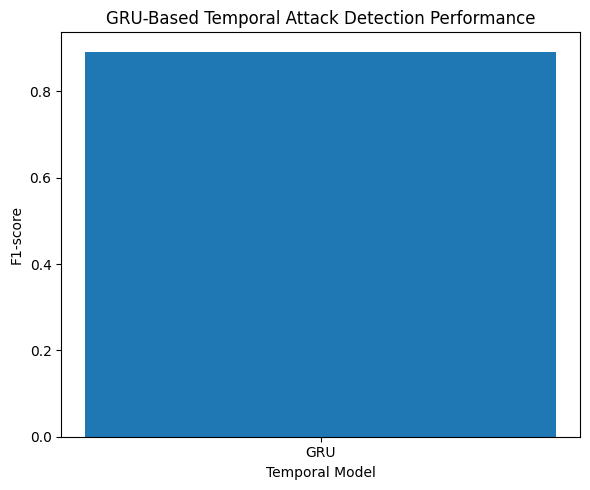

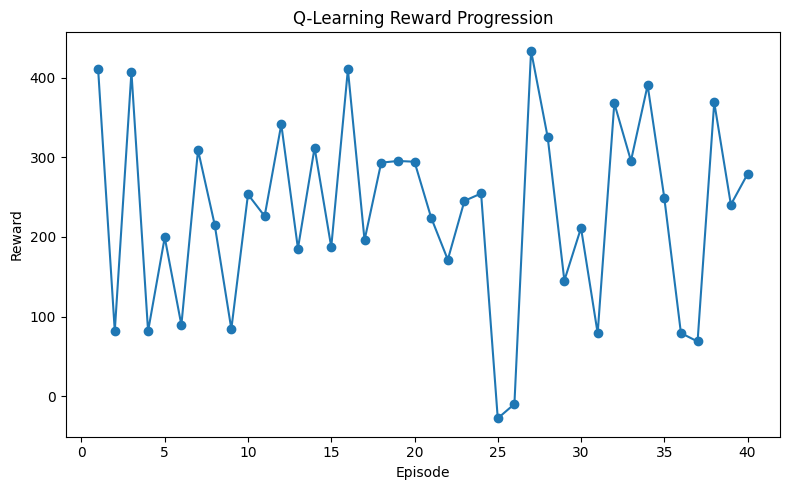

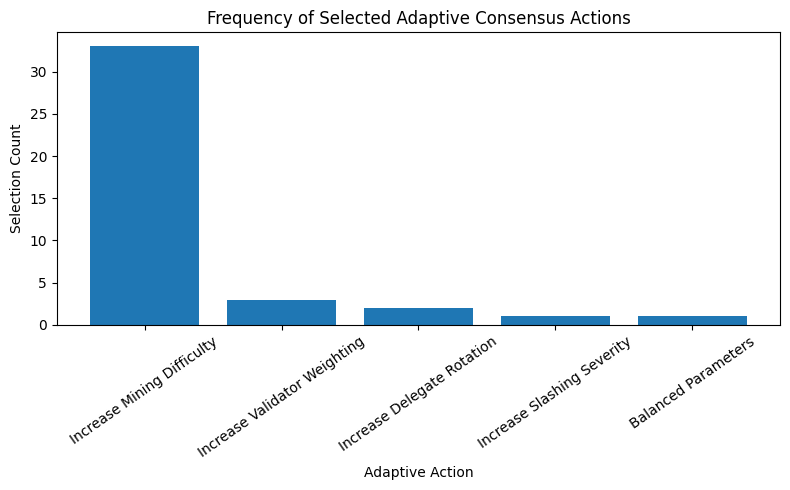

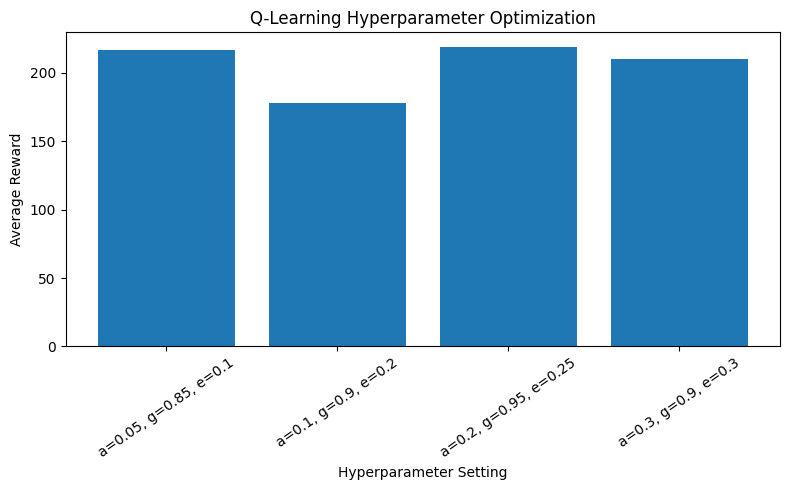

In [25]:
# CELL 20: Visualize GRU temporal detection and Q-Learning adaptive-control results

plt.figure(figsize=(6, 5))
plt.bar(gru_results_df["model"], gru_results_df["f1_score"])
plt.title("GRU-Based Temporal Attack Detection Performance")
plt.xlabel("Temporal Model")
plt.ylabel("F1-score")
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/gru_f1_comparison.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(rl_results_df["episode"], rl_results_df["reward"], marker="o")
plt.title("Q-Learning Reward Progression")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/q_learning_reward_progression.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
action_counts = rl_results_df["selected_action"].value_counts()
plt.bar(action_counts.index, action_counts.values)
plt.title("Frequency of Selected Adaptive Consensus Actions")
plt.xlabel("Adaptive Action")
plt.ylabel("Selection Count")
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/q_learning_selected_actions.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    rl_hpo_results_df.apply(
        lambda row: f"a={row['alpha']}, g={row['gamma']}, e={row['epsilon']}",
        axis=1
    ),
    rl_hpo_results_df["average_reward"]
)
plt.title("Q-Learning Hyperparameter Optimization")
plt.xlabel("Hyperparameter Setting")
plt.ylabel("Average Reward")
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/q_learning_hyperparameter_optimization.png", dpi=300)
plt.show()

In [26]:
# CELL 21: Save advanced AI and adaptive-control results for manuscript reporting

advanced_summary = {
    "best_supervised_ml_model": optimized_ml_results_df.sort_values("f1_score", ascending=False).iloc[0]["model"],
    "best_supervised_ml_f1": optimized_ml_results_df["f1_score"].max(),
    "temporal_model": "GRU",
    "gru_temporal_f1": gru_results_df["f1_score"].iloc[0],
    "gru_best_parameters": gru_results_df["best_parameters"].iloc[0],
    "best_rl_average_reward": rl_hpo_results_df["average_reward"].max(),
    "best_rl_hyperparameters": str(
        rl_hpo_results_df.sort_values("average_reward", ascending=False).iloc[0].to_dict()
    )
}

advanced_summary_df = pd.DataFrame([advanced_summary])
advanced_summary_df.to_csv(f"{RESULT_DIR}/advanced_ai_adaptive_control_summary.csv", index=False)

display(advanced_summary_df)

,best_supervised_ml_model,best_supervised_ml_f1,temporal_model,gru_temporal_f1,gru_best_parameters,best_rl_average_reward,best_rl_hyperparameters
0,Random Forest,0.98727,GRU,0.892447,"{'units': 32, 'dropout': 0.2, 'learning_rate':...",218.736426,"{'alpha': 0.2, 'gamma': 0.95, 'epsilon': 0.25,..."


In [27]:
# CELL 22: Zip and download all results
# Package all generated datasets, tables, and figures into a compressed archive after all experiments have completed.

import shutil
from google.colab import files

zip_base = BASE_DIR
zip_path = f"{zip_base}.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    zip_base,
    "zip",
    RESULT_DIR
)

files.download(zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>